<a href="https://colab.research.google.com/github/francobarrionuevoenv21/radiometric_uncertainty_sar/blob/main/notebook_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Clone repo from github
! git clone https://github.com/francobarrionuevoenv21/radiometric_uncertainty_sar.git

# Move to the folder containing the .py file
%cd radiometric_uncertainty_sar/radunc

Cloning into 'radiometric_uncertainty_sar'...
remote: Enumerating objects: 16, done.
remote: Total 16 (delta 0), reused 0 (delta 0), pack-reused 16 (from 2)
Receiving objects: 100% (16/16), 42.84 MiB | 16.18 MiB/s, done.
Updating files: 100% (9/9), done.
/content/radiometric_uncertainty_sar/radunc


In [2]:
# Import radiometric uncertainty package modules
from radunc import radunc as rdc
from radunc import plot_error_prob as prb
from radunc import get_unct as unct

# Import general libraries
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio as rio
from rasterio.mask import mask

In [3]:
# Define parameters
TIF_PATH = 'https://github.com/francobarrionuevoenv21/radiometric_uncertainty_sar/raw/refs/heads/main/data_test/envisat_wsm_2005_09_12_hh_pot_cal_cg_gk5wgs84_nn_sub_SpkGamma11.tif' # ENVISAT HH image speckle filtered with a Gamma 11x11 window
SAMPLES_PATH = 'https://github.com/francobarrionuevoenv21/radiometric_uncertainty_sar/raw/refs/heads/main/data_test/muestras_merged4326.geojson' # Homogeneus samples vector
SAMPLES_COL = 'nombre' # Samples column name
LIST_CI = [91, 95, 99] # List of confidence intervals to evaluate radiometric unvertainty

### Visualize samples

In [4]:
# Open and read image and vector with samples
scene_test = rio.open(TIF_PATH)
gpd_samples = gpd.read_file(SAMPLES_PATH)

# Reproject vector
gpd_samples_rep = gpd_samples.to_crs(scene_test.crs)

In [47]:
test = scene_test.crs.to_epsg()
print(test)

None


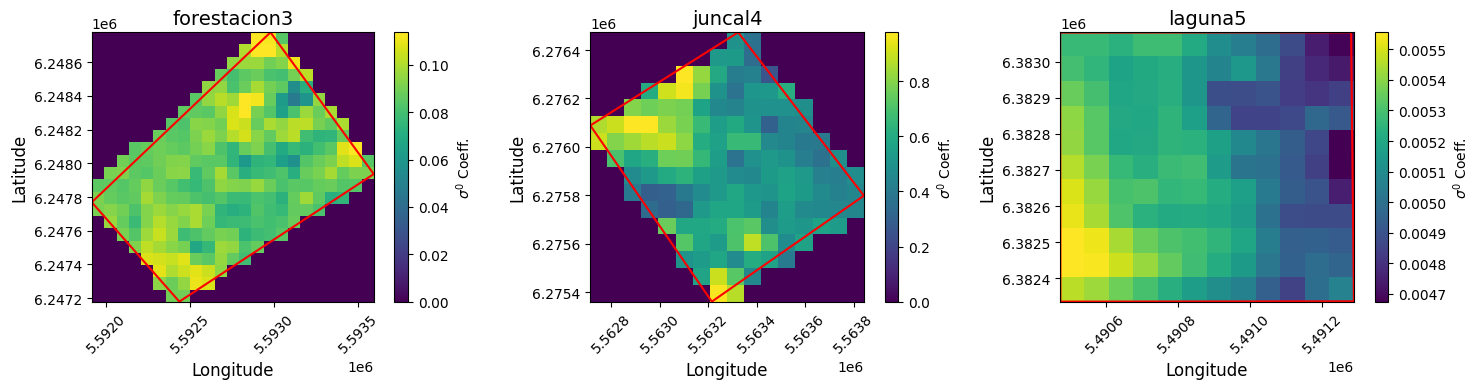

In [30]:
# Plot samples
fig, ax = plt.subplots(1, 3, figsize=(15, 4), tight_layout=True)

for idx, row in gpd_samples_rep.iterrows():
    minx, miny, maxx, maxy = row.geometry.bounds
    plot_extent = (minx, maxx, miny, maxy)

    scene_mask, mask_transform = mask(dataset=scene_test, shapes = [row.geometry], all_touched=True, crop = True)
    im = ax[idx].imshow(scene_mask[0], cmap='viridis',
                   vmin = np.nanpercentile(scene_mask[0], 1), vmax = np.nanpercentile(scene_mask[0], 99),
                   extent = plot_extent)

    fig.colorbar(im, ax=ax[idx], label=r'${\sigma}^{0}$ Coeff.')

    gpd.GeoSeries([row.geometry]).plot(ax=ax[idx], edgecolor='red', linewidth=1.5, facecolor='none')

    ax[idx].set_title(row[SAMPLES_COL], fontsize=14)
    ax[idx].set_ylabel('Latitude', fontsize=12)
    ax[idx].set_xlabel('Longitude', fontsize=12)
    ax[idx].tick_params(axis='x', labelrotation=45)

plt.show()



## Compute Radiometric Uncertainty for each sample from the filtered image

In [53]:
# Run rdc
rdc(TIF_PATH, SAMPLES_PATH, SAMPLES_COL, LIST_CI)

/content/radiometric_uncertainty_sar/radunc/radunc.py:115: UserWarning: CRS mismatch: samples CRS (EPSG:4326) does not match raster CRS (PROJCS["unnamed",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",-90],PARAMETER["central_meridian",-60],PARAMETER["scale_factor",1],PARAMETER["false_easting",5500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]). Reprojecting samples to match raster.
  gdf_samples = read_check_vector(tif_path, samples_path)


,Sample,Mean,Std,ENL,Rad. Unc. 91 [dB],Real. Prob. 91 [%],Rad. Unc. 95 [dB],Real. Prob. 95 [%],Rad. Unc. 99 [dB],Real. Prob. 99 [%]
0,forestacion3,0.088048,0.011379,59.875057,0.96,91.13,1.11,95.05,1.47,99.01
1,juncal4,0.575376,0.156576,13.503689,2.05,91.06,2.39,95.03,3.25,99.00
2,laguna5,0.005134,0.000184,774.556641,0.26,90.42,0.31,95.29,0.40,98.95


In [ ]:
ENL = 4

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Probability vs Radiometric Uncertainty - ENL:4'}, xlabel='Radiometric Uncertainty (dB)', ylabel='Probability (%)'>)

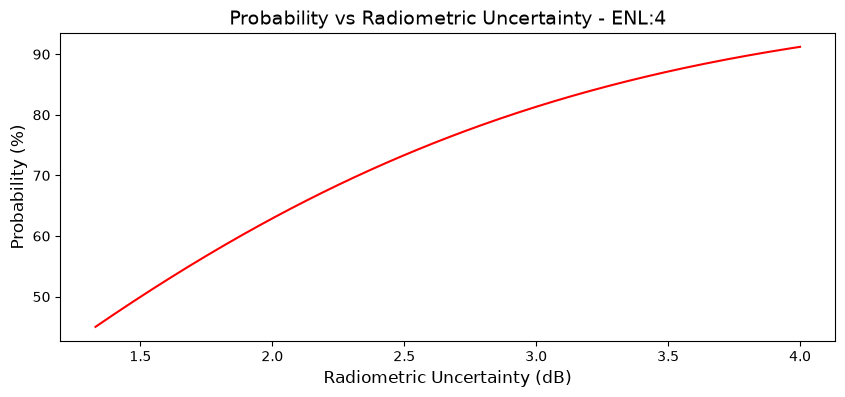

In [ ]:
prb(ENL)